<h1 style="color: White; font-weight: 800;">Capstone 1</h1>

<h2 style="color: blue; font-weight: 800;">
  Index : 
</h2>

<div class="nb-index">
  <ol>
    <li>
      <a href="#data-cleaning">Data Cleaning and Data Pre-processing</a>
      <ol>
        <li><a href="#importing-modules">Importing Modules</a></li>
        <li><a href="#data-ingestion">Data Ingestion</a></li>
        <li><a href="#column-name-meaning">Column Name Meaning</a></li>
        <li><a href="#column-name-changing">Column Name Changing</a></li>
        <li><a href="#category-columns">Category Columns</a></li>
        <li><a href="#binary-values-columns">Binary Values Columns</a></li>
        <li><a href="#numerical-columns">Numerical Columns</a></li>
        <li><a href="#null-value-treatment">NULL Values Treatment</a></li>
      </ol>
    </li>
  </ol>
</div>

 <a id="data-cleaning"></a>

<h1 style="color: red; font-weight: 800;">Data Cleaning and Data Pre-processing</h1>

 <a id="importing-modules"></a>

<h2 style="color: green; font-weight: 800;">Importing Modules</h2>

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

<a id="data-ingestion"></a>

<h2 style="color: green; font-weight: 800;">Data Ingestion</h2>

In [2]:
df = pd.read_csv("HR_Hiring_details_transaction.csv")
df
data = pd.DataFrame(df)


In [3]:
data

,Sno,Candidate_Ref,DOJ_Extended,Duration_to_accept_offer,Notice_Period,Offered_Band,Percent_hike_expected_in_CTC,Percent_hike_offered_in_CTC,Percent_difference_CTC,Joining_Bonus,Candidate_relocate_actual,Gender,Candidate_Source,Rex_in_Yrs,Location_ID,Postal_Code,Age,LOB_Id,Domicile_Id
0,1,2110407,Yes,14,30,E2,-20.79,13.16,42.86,No,No,Female,Agency,7,L001,201301,34.0,1,D6
1,2,2112635,No,18,30,E2,50.00,320.00,180.00,No,No,Male,Employee Referral,8,L002,600020,34.0,2,D9
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,No,Male,Agency,4,L001,201301,27.0,2,D10
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,No,Male,Employee Referral,4,L001,201301,34.0,2,D3
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,Yes,Male,Employee Referral,6,L001,201301,34.0,2,D21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8990,12319,3822427,No,4,0,E1,191.67,191.67,0.00,No,No,Male,Employee Referral,1,L002,600020,34.0,1,D21
8991,12327,3828206,Yes,2,0,E1,150.00,150.00,0.00,No,No,Female,Direct,3,L002,600020,34.0,4,D9
8992,12331,3834159,No,0,0,E2,35.42,35.42,0.00,No,No,Male,Direct,5,L001,201301,34.0,2,D18
8993,12332,3835433,No,0,30,E1,76.92,53.85,-13.04,No,No,Male,Direct,4,L001,201301,34.0,2,D2


In [4]:
cols = list(data.columns)
print(cols)

['Sno', 'Candidate_Ref', 'DOJ_Extended', 'Duration_to_accept_offer', 'Notice_Period', 'Offered_Band', 'Percent_hike_expected_in_CTC', 'Percent_hike_offered_in_CTC', 'Percent_difference_CTC', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Rex_in_Yrs', 'Location_ID', 'Postal_Code', 'Age', 'LOB_Id', 'Domicile_Id']


In [5]:
row,column = data.shape
print(f"No of Rows : {row}\nNo of Columns = {column}")

No of Rows : 8995
No of Columns = 19


In [6]:
data.head()

,Sno,Candidate_Ref,DOJ_Extended,Duration_to_accept_offer,Notice_Period,Offered_Band,Percent_hike_expected_in_CTC,Percent_hike_offered_in_CTC,Percent_difference_CTC,Joining_Bonus,Candidate_relocate_actual,Gender,Candidate_Source,Rex_in_Yrs,Location_ID,Postal_Code,Age,LOB_Id,Domicile_Id
0,1,2110407,Yes,14,30,E2,-20.79,13.16,42.86,No,No,Female,Agency,7,L001,201301,34.0,1,D6
1,2,2112635,No,18,30,E2,50.00,320.00,180.00,No,No,Male,Employee Referral,8,L002,600020,34.0,2,D9
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,No,Male,Agency,4,L001,201301,27.0,2,D10
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,No,Male,Employee Referral,4,L001,201301,34.0,2,D3
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,Yes,Male,Employee Referral,6,L001,201301,34.0,2,D21


In [7]:
data.sample(10)

,Sno,Candidate_Ref,DOJ_Extended,Duration_to_accept_offer,Notice_Period,Offered_Band,Percent_hike_expected_in_CTC,Percent_hike_offered_in_CTC,Percent_difference_CTC,Joining_Bonus,Candidate_relocate_actual,Gender,Candidate_Source,Rex_in_Yrs,Location_ID,Postal_Code,Age,LOB_Id,Domicile_Id
7219,9338,3334477,No,4,30,E1,37.93,37.93,0.00,No,No,Male,Direct,4,L001,201301,34.0,5,D11
425,560,2121112,No,3,30,NaN,0.00,-6.45,-6.45,No,No,Male,Direct,8,L004,560034,NaN,2,D4
4374,5823,2613560,Yes,67,30,E1,44.58,26.51,-12.50,No,No,Male,Agency,3,L002,600020,26.0,1,D15
6024,7875,3239136,No,64,30,E1,18.33,18.33,0.00,No,No,Male,Direct,2,L002,600020,24.0,4,D21
937,1205,2207871,Yes,0,0,E2,25.00,5.42,-15.67,No,Yes,Male,Direct,7,L001,201301,35.0,7,D4
6122,7990,3250182,No,37,30,E1,14.29,14.29,0.00,No,No,Female,Direct,3,L002,600020,25.0,4,D6
6528,8468,3274232,No,17,30,E1,66.67,66.67,0.00,No,No,Female,Direct,4,L001,201301,28.0,5,D22
8791,11882,3664089,No,5,0,E2,20.00,10.00,-8.33,No,No,Male,Direct,8,L001,201301,34.0,6,D2
497,657,2147122,Yes,12,30,E1,42.86,42.86,0.00,No,Yes,Male,Direct,1,L002,600020,23.0,1,D5
7537,9764,3374991,No,1,45,E3,42.86,42.86,0.00,No,No,Male,Employee Referral,5,L002,600020,34.0,2,D2


<a id="column-name-meaning"></a>

<h2 style="color: green; font-weight: 800;">Column Name Meaning</h2>

1. *Sno* = Serial Number
2. *Candidate_Ref* = Candidate Reference Number
3. *DOJ_Extended* = Date of Join extended
4. *Duration_to_accept_offer* = Days taken by the candidate to accept the offer
5. *Notice_Period* = Notice Period
6. *Offered_Band* = Job grade or Employment Level offered to the candidate
7. *Percent_hike_expected_in_CTC* = The percentage of hike in CTC the candidate expected from current ctc
8. *Percent_hike_offered_in_CTC* = The percentage of hike offered from the firm to the candidate
9. *Percent_difference_CTC* = Percentage difference in expected ctc and current ctc
10. *Joining_Bonus* = Joining bonus offered or not to the candidate
11. *Candidate_relocate_actual* = Whether relocation was required or accepted by the candidate.
12. *Gender*
13. *Candidate_Source* = Through which source the candidate is offered 
14. *Rex_in_Yrs* = Related experiences in year
15. *Location_ID*
16. *Postal_Code*
17. *Age*
18. *LOB_Id* = Line of Business ID it can be the department or the domain of the candidate
19. *Domicial_Id* = It means the candidate’s home state or residential location

<a id="column-name-changing"></a>

<h2 style="color: green; font-weight: 800;">Column Name Changing</h2>

`Changing columns' name to more relatable name`

1. *Candidate_Ref* = **Candidate_ID**
2. *Duration_to_accept_offer* = **Acceptance_days**
3. *Percent_hike_expected_in_CTC* = **Expected_CTC_hike_pct**
4. *Percent_hike_offered_in_CTC* = **Offered_CTC_hike_pct**
5. *Percent_difference_CTC* = **CTC_diff_pct**
6. *Rex_in_Yrs* = **Experience_years**


In [8]:
data.rename(columns = {"Candidate_Ref" : "Candidate_ID", "Duration_to_accept_offer" : "Acceptance_days"
                      ,"Percent_hike_expected_in_CTC" : "Expected_CTC_hike_pct", "Percent_hike_offered_in_CTC" : "Offered_CTC_hike_pct",
                      "Percent_difference_CTC" : "CTC_diff_pct", "Rex_in_Yrs" : "Experience_years"}, inplace=True)

data.head()

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,Candidate_Source,Experience_years,Location_ID,Postal_Code,Age,LOB_Id,Domicile_Id
0,1,2110407,Yes,14,30,E2,-20.79,13.16,42.86,No,No,Female,Agency,7,L001,201301,34.0,1,D6
1,2,2112635,No,18,30,E2,50.00,320.00,180.00,No,No,Male,Employee Referral,8,L002,600020,34.0,2,D9
2,3,2112838,No,3,45,E2,42.84,42.84,0.00,No,No,Male,Agency,4,L001,201301,27.0,2,D10
3,4,2115021,No,26,30,E2,42.84,42.84,0.00,No,No,Male,Employee Referral,4,L001,201301,34.0,2,D3
4,5,2115125,Yes,1,120,E2,42.59,42.59,0.00,No,Yes,Male,Employee Referral,6,L001,201301,34.0,2,D21


In [9]:
cols = list(data.columns)
print(f"Columns = {cols}")

Columns = ['Sno', 'Candidate_ID', 'DOJ_Extended', 'Acceptance_days', 'Notice_Period', 'Offered_Band', 'Expected_CTC_hike_pct', 'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Experience_years', 'Location_ID', 'Postal_Code', 'Age', 'LOB_Id', 'Domicile_Id']


<a id="category-columns"></a>

<h2 style="color: green; font-weight: 800;">Category Columns</h2>

`nan value only in Offered_Band`

In [10]:
category_cols = list(data.select_dtypes(exclude='number').columns)
print(f"Category columns = {category_cols}")

Category columns = ['DOJ_Extended', 'Offered_Band', 'Joining_Bonus', 'Candidate_relocate_actual', 'Gender', 'Candidate_Source', 'Location_ID', 'Domicile_Id']


In [11]:
for col in category_cols:
    print(f"Unique values of ||{col}|| = {data[col].unique()}")

# There is Null values in ->
# 1.Offered_Band
# 2.Location_ID

Unique values of ||DOJ_Extended|| = ['Yes' 'No']
Unique values of ||Offered_Band|| = ['E2' 'E1' 'E3' nan 'E0']
Unique values of ||Joining_Bonus|| = ['No' 'Yes']
Unique values of ||Candidate_relocate_actual|| = ['No' 'Yes']
Unique values of ||Gender|| = ['Female' 'Male']
Unique values of ||Candidate_Source|| = ['Agency' 'Employee Referral' 'Direct']
Unique values of ||Location_ID|| = ['L001' 'L002' 'L003' 'L004' 'L005' 'L006' 'L007' 'L008' 'Null' 'L009'
 'L010']
Unique values of ||Domicile_Id|| = ['D6' 'D9' 'D10' 'D3' 'D21' 'D24' 'D23' 'D5' 'D13' 'D4' 'D7' 'D19' 'D11'
 'D16' 'D18' 'D15' 'D14' 'D20' 'D2' 'D12' 'D8' 'D17' 'D22' 'D1']


<a id="binary-values-columns"></a>

<h2 style="color: green; font-weight: 800;">Binary Values Columns</h2>

`There is no inconsistency as there is only 'Yes' or 'No'`

In [12]:
data['DOJ_Extended'].unique()

array(['Yes', 'No'], dtype=object)

In [13]:
data['Joining_Bonus'].unique()

array(['No', 'Yes'], dtype=object)

In [14]:
data['Candidate_relocate_actual'].unique()

array(['No', 'Yes'], dtype=object)

<a id="numerical-columns"></a>

<h2 style="color: green; font-weight: 800;">Numerical Columns</h2>


In [15]:
numerical_cols = list(data.select_dtypes(include = 'number').columns)
print(f"Numerical columns = {numerical_cols}")

Numerical columns = ['Sno', 'Candidate_ID', 'Acceptance_days', 'Notice_Period', 'Expected_CTC_hike_pct', 'Offered_CTC_hike_pct', 'CTC_diff_pct', 'Experience_years', 'Postal_Code', 'Age', 'LOB_Id']


In [16]:
data[numerical_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sno                    8995 non-null   int64  
 1   Candidate_ID           8995 non-null   int64  
 2   Acceptance_days        8995 non-null   int64  
 3   Notice_Period          8995 non-null   int64  
 4   Expected_CTC_hike_pct  8995 non-null   float64
 5   Offered_CTC_hike_pct   8995 non-null   float64
 6   CTC_diff_pct           8995 non-null   float64
 7   Experience_years       8995 non-null   int64  
 8   Postal_Code            8995 non-null   int64  
 9   Age                    8980 non-null   float64
 10  LOB_Id                 8995 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 773.1 KB


### Checking for NULL values

In [17]:
data[numerical_cols].isna().sum()

# There is NULL values in ->
# 1. Age 

Sno                       0
Candidate_ID              0
Acceptance_days           0
Notice_Period             0
Expected_CTC_hike_pct     0
Offered_CTC_hike_pct      0
CTC_diff_pct              0
Experience_years          0
Postal_Code               0
Age                      15
LOB_Id                    0
dtype: int64

In [18]:
data['Age'].isna().sum()

np.int64(15)

In [19]:
data['Age'].unique()

array([34., 27., 32., 26., 29., 36., 30., 31., 40., 28., 33., 25., 44.,
       23., 41., 20., 37., 24., 35., 50., 42., 38., 39., 21., nan, 45.,
       46., 43., 22., 49., 47., 48., 60., 51.])

### Checking for duplicate values

In [20]:
data[numerical_cols].duplicated().sum()
# There is no duplicate value in numerical columns

np.int64(0)

`Columns to check further - Either will change data type or remove in EDA`

- Postal_Code
- LOB_Id

In [21]:
data['Postal_Code'].unique()

array([201301, 600020, 122107, 560034, 500004, 700027, 682001, 411002,
       600018, 400001, 560002, 382460, 560063, 500045, 411006])

In [22]:
data['LOB_Id'].unique()

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [23]:
data['Notice_Period'].unique()
# Have to deep it as numeric (Imp)

array([ 30,  45, 120,   0,  75,  60,  90])

In [24]:
data['Acceptance_days'].unique()
# There is no negative(-) value, so this column is not imbalance.

array([ 14,  18,   3,  26,   1,  17,  37,  16,   6, 120,  44,   7,  98,
         0,  83,  32,  19,   4,  38,  24,  10,  53,   5,  46,   2,  31,
        54,  33, 105,  69,  68,  84,  28, 126, 106,  90,  21,  36,  34,
        20,  13,   8,  42,  12, 103,  43,  60,  23,  67,  15,  45,  25,
        47,  11,  48,  74,  30,  40,  35,  58,  29,  86,  51,  50,  39,
        57,  93,  55,  71,  56,  66,  62,   9,  64, 107,  27,  78,  22,
        49,  92,  61,  79,  77, 108,  70,  82, 210,  80,  97,  41,  59,
        88,  99,  63, 111,  87,  95,  52,  96,  91, 101,  65, 140,  76,
        73, 123, 104,  72, 117, 109,  89, 127,  81,  85,  75, 118, 114,
       110, 129, 124, 116, 181,  94, 121, 119, 102, 113, 115, 125, 131,
       100, 130, 224, 143, 122, 163])

In [25]:
print(data['Offered_CTC_hike_pct'][data['Offered_CTC_hike_pct'] < 0])
# There are many rows that have offered ctc hike percentage in negative value.
# So this negative values are important, because candidates with negative value of percentage ctc hike might not join the firm
print(f"\nNo of rows with negative(-) offered ctc hike percentage = {data['Offered_CTC_hike_pct'][data['Offered_CTC_hike_pct'] < 0].count()}")

7      -20.00
8      -22.22
10     -60.53
15     -27.31
29      -2.17
        ...  
8872   -17.04
8882    -6.67
8958    -2.86
8967   -10.00
8977   -14.29
Name: Offered_CTC_hike_pct, Length: 446, dtype: float64

No of rows with negative(-) offered ctc hike percentage = 446


<a id="null-value-treatment"></a>

<h2 style="color: green; font-weight: 800;">NULL Values Treatment</h2>

`Columns with NULL values :`

1. Age
2. Offered_Band
3. Location_ID

In [26]:
data.isna().sum()

# One thing here -> 
# The Data type of Location_ID is object, but its showing 0 null value here. That means there is NULL value as Object.

Sno                           0
Candidate_ID                  0
DOJ_Extended                  0
Acceptance_days               0
Notice_Period                 0
Offered_Band                 13
Expected_CTC_hike_pct         0
Offered_CTC_hike_pct          0
CTC_diff_pct                  0
Joining_Bonus                 0
Candidate_relocate_actual     0
Gender                        0
Candidate_Source              0
Experience_years              0
Location_ID                   0
Postal_Code                   0
Age                          15
LOB_Id                        0
Domicile_Id                   0
dtype: int64

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8995 entries, 0 to 8994
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sno                        8995 non-null   int64  
 1   Candidate_ID               8995 non-null   int64  
 2   DOJ_Extended               8995 non-null   object 
 3   Acceptance_days            8995 non-null   int64  
 4   Notice_Period              8995 non-null   int64  
 5   Offered_Band               8982 non-null   object 
 6   Expected_CTC_hike_pct      8995 non-null   float64
 7   Offered_CTC_hike_pct       8995 non-null   float64
 8   CTC_diff_pct               8995 non-null   float64
 9   Joining_Bonus              8995 non-null   object 
 10  Candidate_relocate_actual  8995 non-null   object 
 11  Gender                     8995 non-null   object 
 12  Candidate_Source           8995 non-null   object 
 13  Experience_years           8995 non-null   int64

## Treatment of `Age` column

In [28]:
data['Age'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8995 entries, 0 to 8994
Series name: Age
Non-Null Count  Dtype  
--------------  -----  
8980 non-null   float64
dtypes: float64(1)
memory usage: 70.4 KB


In [29]:
data['Age']

0       34.0
1       34.0
2       27.0
3       34.0
4       34.0
        ... 
8990    34.0
8991    34.0
8992    34.0
8993    34.0
8994    34.0
Name: Age, Length: 8995, dtype: float64

In [30]:
data['Age'].unique()

array([34., 27., 32., 26., 29., 36., 30., 31., 40., 28., 33., 25., 44.,
       23., 41., 20., 37., 24., 35., 50., 42., 38., 39., 21., nan, 45.,
       46., 43., 22., 49., 47., 48., 60., 51.])

In [31]:
Age_missing = int(data['Age'].isna().sum())
Age_min = data['Age'].min()
Age_max = data['Age'].max()

Age_median = data['Age'].median()
Age_mean = data['Age'].mean()

print(f"Null values in Age column = {Age_missing}")
print(f"Min Age = {Age_min}")
print(f"Max Age = {Age_max}")
print(f"Median Age = {Age_median}")
print(f"Mean Age = {Age_mean}")

Null values in Age column = 15
Min Age = 20.0
Max Age = 60.0
Median Age = 29.0
Mean Age = 29.912026726057906


In [32]:
data['Age'][data["Age"] > Age_mean].count()

np.int64(4481)

In [33]:
data['Age'][data["Age"] <= Age_mean].count()

np.int64(4499)

In [34]:
data['Age'][data["Age"] > 35].count()

np.int64(435)

In [35]:
data['Age'][data["Age"] > 40].count()

np.int64(77)

In [36]:
data['Age'][data["Age"] > 50].count()

np.int64(2)

### Diagram of Age column distribution

In [37]:
age_count = pd.DataFrame(data['Age'].dropna().value_counts())
age_count

,count
Age,
34.0,2142
27.0,903
26.0,839
28.0,770
25.0,676
29.0,630
30.0,575
31.0,485
24.0,397


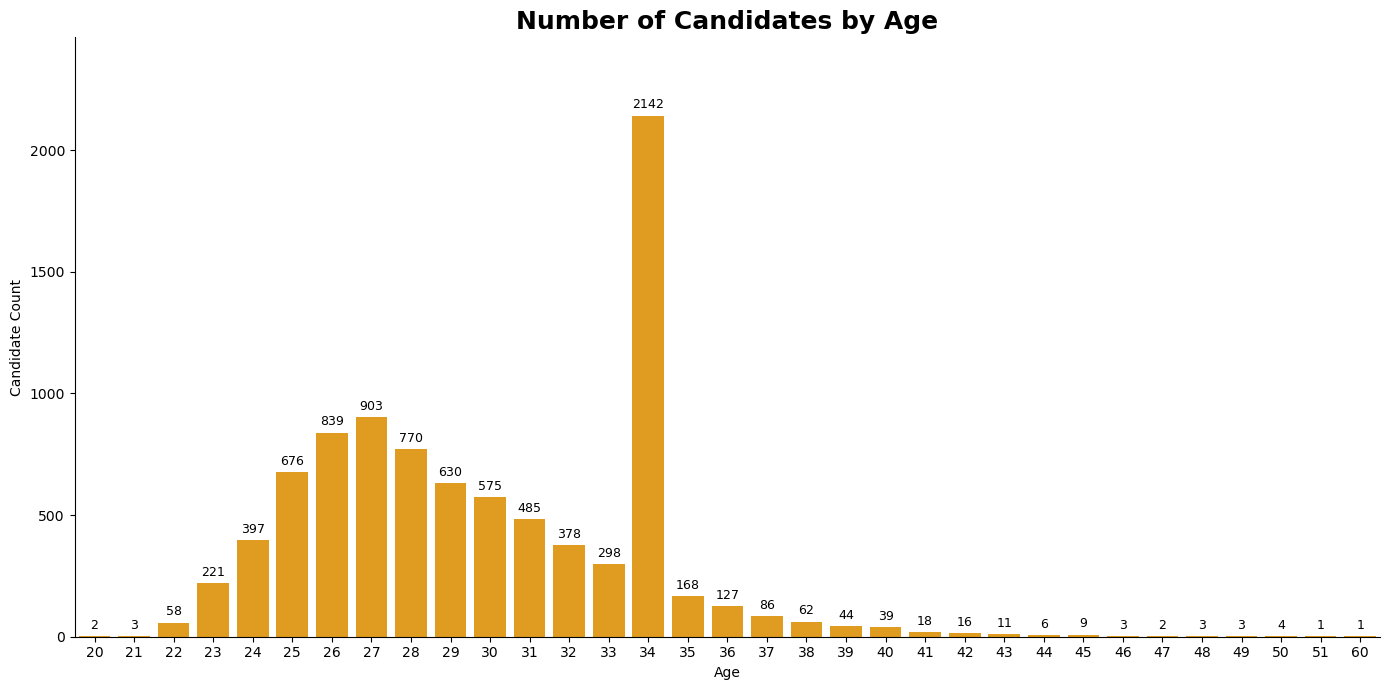

In [46]:
age_count2 = (
    data["Age"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

x = age_count2.index.tolist()
y = age_count2.tolist()

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    x=x,
    y=y,
    color="orange"
)

ax.bar_label(ax.containers[0], padding=3, fontsize=9)

plt.title("Number of Candidates by Age", fontsize=18, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Candidate Count")
plt.ylim(0, max(y) * 1.15)

sns.despine()
plt.tight_layout()
plt.show()

### Outliers check for `Age` column

In [47]:
age = pd.to_numeric(data["Age"].dropna())

# Calculate IQR
Q1 = age.quantile(0.25)
Q3 = age.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = age[(age < lower_bound) | (age > upper_bound)]

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Number of outliers: {len(outliers)}")
print(f"Outlier values : {outliers.unique()}")

Q1: 27.0
Q3: 34.0
IQR: 7.0
Lower bound: 16.5
Upper bound: 44.5
Number of outliers: 26
Outlier values : [50. 45. 46. 49. 47. 48. 60. 51.]


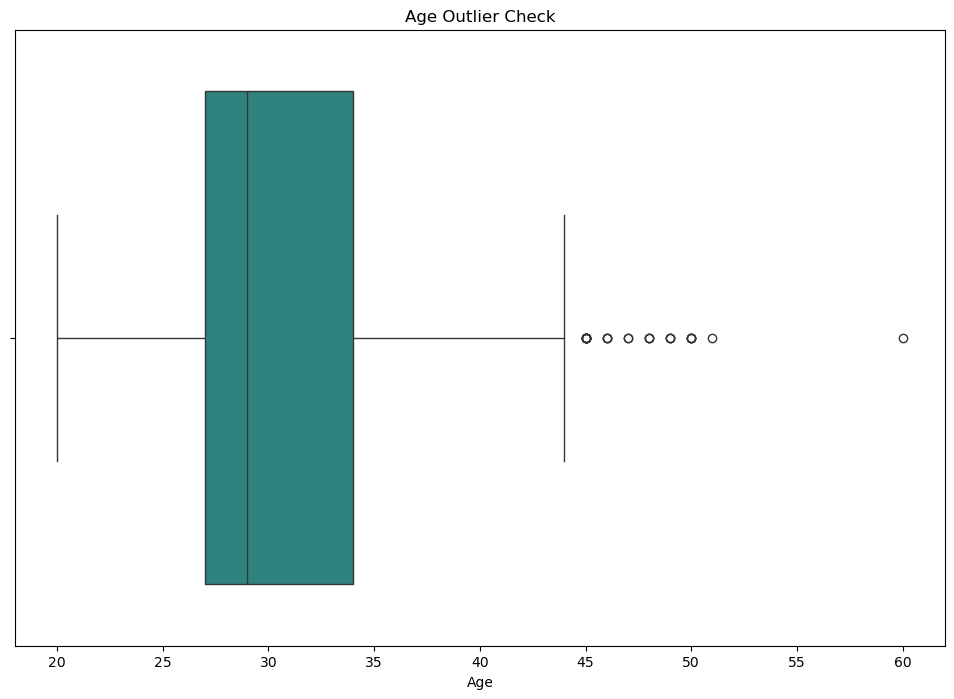

In [48]:
plt.figure(figsize=(12,8))

sns.boxplot(x=data["Age"].dropna(), palette='viridis')

plt.title("Age Outlier Check")
plt.xlabel("Age")
plt.show()

The decreasing number of candidates at higher ages indicates that the distribution is concentrated around younger ages and has a right tail. The mean age is approximately 29.91, while the median is 29. The IQR method flags ages above 44.5 as statistical outliers.
Because the higher ages can pull the mean upward, the median is the safer replacement value for the 15 missing ages. It represents the typical candidate more robustly and results in an actual whole-number age.

In [49]:
data[data['Age'].isna()]

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,Candidate_Source,Experience_years,Location_ID,Postal_Code,Age,LOB_Id,Domicile_Id
397,524,2117861,Yes,62,60,E2,40.85,40.85,0.00,No,No,Male,Employee Referral,2,L001,201301,NaN,2,D15
406,535,2118480,No,4,30,E1,89.66,48.28,-21.82,No,No,Male,Direct,3,L001,201301,NaN,5,D12
414,543,2119541,Yes,2,0,E2,56.86,37.25,-12.50,No,No,Female,Employee Referral,3,L001,201301,NaN,2,D15
425,560,2121112,No,3,30,NaN,0.00,-6.45,-6.45,No,No,Male,Direct,8,L004,560034,NaN,2,D4
446,589,2128251,No,58,30,E2,50.33,50.33,0.00,No,No,Male,Direct,7,L002,600020,NaN,2,D24
485,644,2143765,Yes,41,90,E1,10.77,10.77,0.00,No,No,Male,Employee Referral,5,L002,600020,NaN,4,D7
526,691,2151137,No,4,45,E3,20.83,20.83,0.00,No,No,Male,Employee Referral,13,L001,201301,NaN,2,D23
573,751,2160044,No,0,0,E2,17.78,14.31,-2.94,Yes,No,Male,Agency,9,L003,122107,NaN,2,D13
616,809,2167868,No,5,30,E1,20.00,-4.00,-20.00,No,Yes,Male,Direct,2,L001,201301,NaN,2,D13
674,889,2177940,No,0,30,E1,13.46,34.56,18.60,No,No,Male,Employee Referral,3,L003,122107,NaN,5,D22


### Filling NULL values in `Age` column with `Median`

In [50]:
data['Age'].fillna(Age_median, inplace=True)

In [51]:
data['Age'].isna().sum()

np.int64(0)

In [56]:
data.isna().sum()

Sno                           0
Candidate_ID                  0
DOJ_Extended                  0
Acceptance_days               0
Notice_Period                 0
Offered_Band                 13
Expected_CTC_hike_pct         0
Offered_CTC_hike_pct          0
CTC_diff_pct                  0
Joining_Bonus                 0
Candidate_relocate_actual     0
Gender                        0
Candidate_Source              0
Experience_years              0
Location_ID                   0
Postal_Code                   0
Age                           0
LOB_Id                        0
Domicile_Id                   0
dtype: int64

## Treatment of `Offered_Band` column

In [57]:
data['Offered_Band']

0       E2
1       E2
2       E2
3       E2
4       E2
        ..
8990    E1
8991    E1
8992    E2
8993    E1
8994    E1
Name: Offered_Band, Length: 8995, dtype: object

In [58]:
data['Offered_Band'].unique()

array(['E2', 'E1', 'E3', nan, 'E0'], dtype=object)

In [59]:
data['Offered_Band'].value_counts()

Offered_Band
E1    5565
E2    2704
E3     502
E0     211
Name: count, dtype: int64

In [60]:
data['Offered_Band'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8995 entries, 0 to 8994
Series name: Offered_Band
Non-Null Count  Dtype 
--------------  ----- 
8982 non-null   object
dtypes: object(1)
memory usage: 70.4+ KB


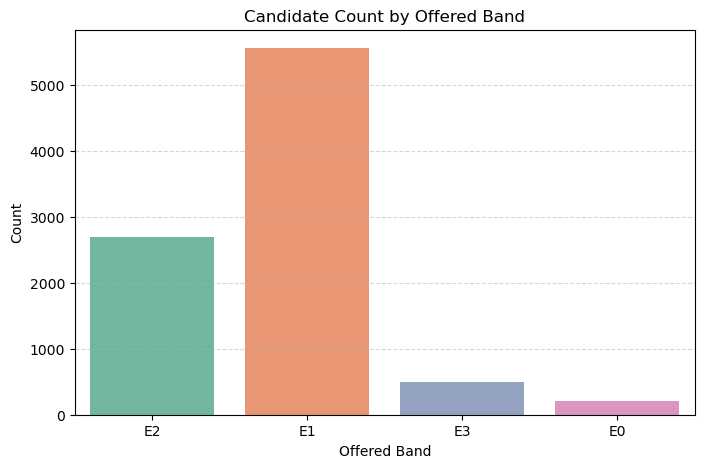

In [91]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Offered_Band",
    hue="Offered_Band",
    palette="Set2",
    legend=False
)

plt.xlabel("Offered Band")
plt.ylabel("Count")
plt.title("Candidate Count by Offered Band")
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.show()

In [95]:
data[data['Offered_Band'].isna()]

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,Candidate_Source,Experience_years,Location_ID,Postal_Code,Age,LOB_Id,Domicile_Id
27,30,2207823,Yes,19,30,NaN,42.85,42.85,0.00,No,No,Male,Direct,7,L001,201301,28.0,2,D13
55,68,2286381,Yes,14,30,NaN,-12.50,-12.50,0.00,No,No,Male,Direct,3,L006,700027,31.0,7,D4
79,102,2365129,No,4,30,NaN,42.86,42.86,0.00,No,No,Male,Direct,2,L007,682001,24.0,2,D12
109,139,2452418,Yes,32,30,NaN,45.30,19.66,-17.65,No,Yes,Male,Agency,7,L004,560034,30.0,6,D15
138,177,2569520,No,5,30,NaN,-48.25,-48.25,0.00,No,No,Male,Employee Referral,9,L002,600020,31.0,2,D20
167,213,2780669,Yes,29,60,NaN,33.33,266.67,175.00,No,No,Male,Agency,9,L001,201301,32.0,1,D23
194,245,2845929,Yes,55,30,NaN,37.50,25.00,-9.09,No,Yes,Female,Employee Referral,3,L004,560034,25.0,2,D15
227,291,3211382,No,4,30,NaN,42.85,42.85,0.00,No,No,Male,Agency,4,L004,560034,30.0,2,D22
281,360,3300563,Yes,29,30,NaN,-30.00,-30.60,-0.85,No,No,Male,Employee Referral,8,L001,201301,33.0,5,D19
319,402,3379843,No,17,0,NaN,-12.04,-12.04,0.00,No,No,Male,Agency,2,L002,600020,28.0,2,D3


In [97]:
data[data['Offered_Band'] == 'E1'].head()

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,Candidate_Source,Experience_years,Location_ID,Postal_Code,Age,LOB_Id,Domicile_Id
5,6,2117167,Yes,17,30,E1,42.83,42.83,0.00,No,No,Male,Employee Referral,2,L001,201301,34.0,2,D24
7,9,2127572,Yes,16,0,E1,-20.00,-20.00,0.00,No,No,Female,Direct,8,L001,201301,34.0,3,D6
8,11,2138169,No,1,30,E1,-22.22,-22.22,0.00,No,No,Female,Employee Referral,3,L003,122107,26.0,4,D5
9,12,2143362,No,6,30,E1,240.00,220.00,-5.88,No,No,Male,Employee Referral,3,L002,600020,34.0,5,D23
18,21,2173730,No,1,30,E1,-13.42,42.86,65.00,No,No,Male,Direct,1,L003,122107,34.0,2,D7


As there is only only 13 missing values in column `Offered_Band`, we can replace this with the `Mode` of the column i.e. E1

In [99]:
OB_mode = data['Offered_Band'].mode()[0]
OB_mode

'E1'

### Filling `Offered_Band` with `Mode` i.e. `E1`

In [103]:
data['Offered_Band'].fillna(OB_mode, inplace = True)

In [104]:
data['Offered_Band'].isna().sum()

np.int64(0)

In [105]:
data['Offered_Band'].value_counts()

Offered_Band
E1    5578
E2    2704
E3     502
E0     211
Name: count, dtype: int64

## Treatment of `Location_ID` column

In [106]:
data['Location_ID']

0       L001
1       L002
2       L001
3       L001
4       L001
        ... 
8990    L002
8991    L002
8992    L001
8993    L001
8994    L002
Name: Location_ID, Length: 8995, dtype: object

In [108]:
data['Location_ID'].isna().sum()
# This showing no NULL values.

np.int64(0)

In [109]:
data['Location_ID'].value_counts()

# But here we can see there are 13 NULL valued Rows as Null is in Object type

Location_ID
L002    3150
L001    2727
L004    2230
L005     341
L009     197
L003     146
L006     129
L008      48
Null      13
L007       8
L010       6
Name: count, dtype: int64

In [110]:
data[data['Location_ID'] == 'Null']

,Sno,Candidate_ID,DOJ_Extended,Acceptance_days,Notice_Period,Offered_Band,Expected_CTC_hike_pct,Offered_CTC_hike_pct,CTC_diff_pct,Joining_Bonus,Candidate_relocate_actual,Gender,Candidate_Source,Experience_years,Location_ID,Postal_Code,Age,LOB_Id,Domicile_Id
220,283,3110300,Yes,15,30,E1,42.83,42.83,0.00,No,No,Male,Employee Referral,2,Null,600018,26.0,2,D16
289,369,3318393,Yes,0,30,E1,92.54,80.51,-6.25,No,No,Male,Direct,3,Null,560034,23.0,2,D14
449,594,2128714,Yes,41,45,E1,20.00,4.00,-13.33,No,Yes,Male,Direct,5,Null,560002,33.0,7,D2
1157,1486,2222607,Yes,11,30,E1,42.86,42.86,0.00,No,No,Male,Employee Referral,5,Null,560063,28.0,2,D18
2027,2961,2356982,Yes,1,90,E2,50.00,50.00,0.00,No,No,Male,Direct,3,Null,500004,31.0,2,D24
2562,3600,2394715,Yes,9,30,E1,34.62,34.62,0.00,No,No,Male,Direct,3,Null,500045,30.0,2,D10
2774,3877,2419719,Yes,10,30,E1,86.89,86.89,0.00,No,No,Male,Direct,6,Null,411002,35.0,2,D20
2790,3893,2419919,Yes,20,30,E1,6.48,6.48,0.00,No,No,Male,Direct,5,Null,411006,31.0,2,D8
6941,8977,3304772,Yes,0,30,E1,48.15,57.41,6.25,No,No,Male,Employee Referral,2,Null,400001,27.0,2,D8
7312,9461,3347807,No,4,30,E1,33.33,33.33,0.00,No,Yes,Male,Employee Referral,5,Null,400001,34.0,2,D18


### Plot of `Location_ID`

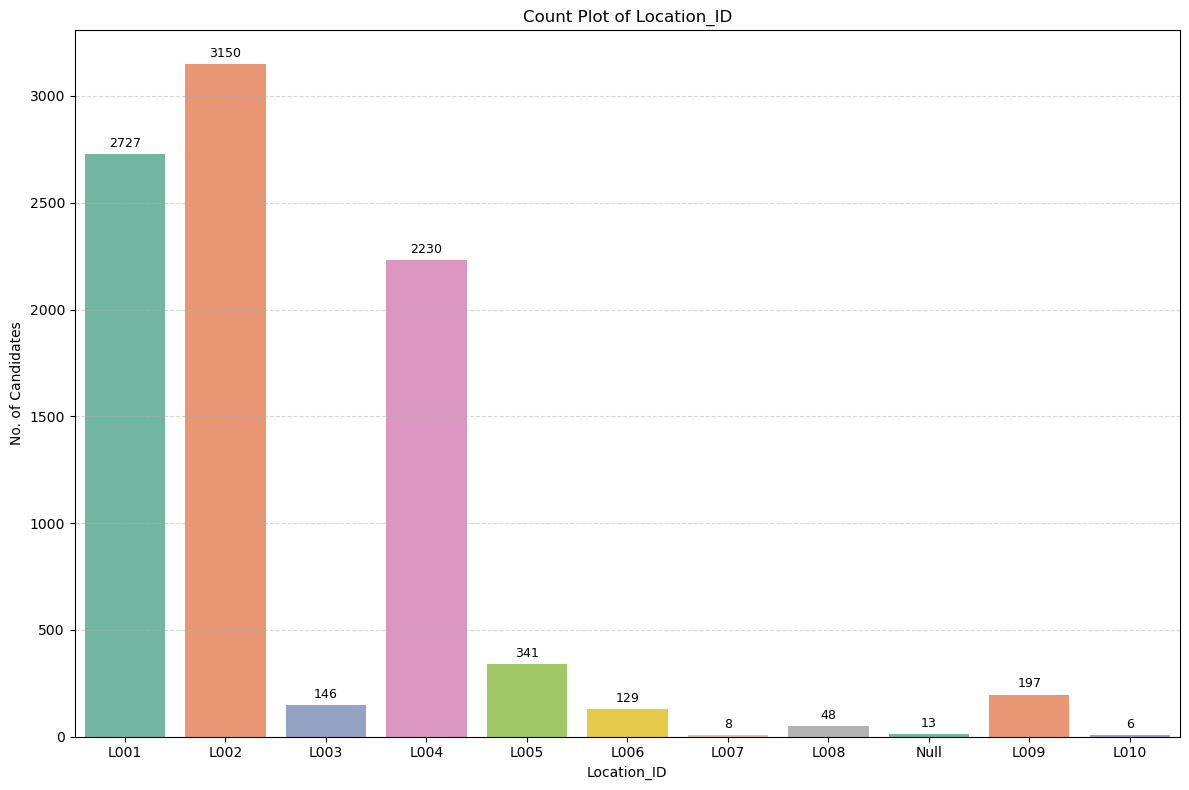

In [122]:
plt.figure(figsize=(12, 8))

ax = sns.countplot(
    data=data,
    x="Location_ID",
    hue="Location_ID",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        padding=3,
        fontsize=9
    )

plt.title("Count Plot of Location_ID")
plt.xlabel("Location_ID")
plt.ylabel("No. of Candidates")
plt.grid(axis="y", alpha=0.5, linestyle="--")

plt.tight_layout()
plt.show()

As there is 13 NULL values and there are some Location_ID(s) which have value_counts less than the
NULL, so in this case `replcaing NULL with "Unknown"` will be a good choice.

In [124]:
data["Location_ID"] = data["Location_ID"].replace("Null", "Unknown")

In [125]:
data['Location_ID'].value_counts()

Location_ID
L002       3150
L001       2727
L004       2230
L005        341
L009        197
L003        146
L006        129
L008         48
Unknown      13
L007          8
L010          6
Name: count, dtype: int64

In [126]:
data.isna().sum()

Sno                          0
Candidate_ID                 0
DOJ_Extended                 0
Acceptance_days              0
Notice_Period                0
Offered_Band                 0
Expected_CTC_hike_pct        0
Offered_CTC_hike_pct         0
CTC_diff_pct                 0
Joining_Bonus                0
Candidate_relocate_actual    0
Gender                       0
Candidate_Source             0
Experience_years             0
Location_ID                  0
Postal_Code                  0
Age                          0
LOB_Id                       0
Domicile_Id                  0
dtype: int64

## There is no NULL values anymore.

In [127]:
"""Data visualization and Full EDA"""

'Data visualization and Full EDA'